In [56]:
# ── Cell 1: Install Dependencies (run once) ───────────────
!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm xgboost emoji


In [57]:
# ── Cell 2: Imports & Device ─────────────────────────────
import os, warnings
import numpy as np, pandas as pd
import emoji
from PIL import Image
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import BertTokenizer, BertModel

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


Running on: cuda


In [58]:
# ── Cell 3: Load & Clean Training Data ─────────────────
train_df = pd.read_csv("train.csv")

# Fill missing values
for col in ['username','biography','followersCount','followsCount',
            'postsCount','fullName','profilePicUrl','joinedRecently','private']:
    if train_df[col].dtype == object:
        train_df[col] = train_df[col].fillna('')
    else:
        train_df[col] = train_df[col].fillna(0)


In [59]:
# ── Cell 4: Text → BERT Embeddings ──────────────────────
def demojize_bio(text):
    return emoji.demojize(str(text), language='en')

train_df['biography_clean'] = train_df['biography'].apply(demojize_bio)
train_df['text_combined'] = train_df['username'] + ' ' + train_df['biography_clean']

# Load BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased").to(device)
bert_model.eval()

class TextDataset(Dataset):
    def __init__(self, texts): self.texts = texts
    def __len__(self): return len(self.texts)
    def __getitem__(self, i): return self.texts[i]

class TextCollator:
    def __init__(self, tok): self.tok = tok
    def __call__(self, batch):
        return self.tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=32)

def extract_text_features(texts):
    ds = TextDataset(texts)
    loader = DataLoader(ds, batch_size=32, collate_fn=TextCollator(tokenizer))
    feats = []
    with torch.no_grad():
        for b in tqdm(loader, desc="BERT Embeddings"):
            b = {k:v.to(device) for k,v in b.items()}
            out = bert_model(**b)
            feats.append(out.pooler_output.cpu().numpy())
    return np.vstack(feats)

text_features_train = extract_text_features(train_df['text_combined'].tolist())


BERT Embeddings: 100%|██████████| 141/141 [00:11<00:00, 12.11it/s]


In [60]:
# ── Cell 5: Images → ResNet Features ────────────────────
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

img_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def extract_image_features(usernames, img_dir="Img_2565"):
    feats = []
    for u in tqdm(usernames, desc="ResNet Features"):
        p = os.path.join(img_dir, f"{u}.jpg")
        if os.path.exists(p):
            try:
                im = Image.open(p).convert('RGB')
                t = img_tf(im).unsqueeze(0).to(device)
                with torch.no_grad():
                    f = resnet(t).squeeze().cpu().numpy()
            except:
                f = np.zeros(2048)
        else:
            f = np.zeros(2048)
        feats.append(f)
    return np.vstack(feats)

image_features_train = extract_image_features(train_df['username'])


ResNet Features: 100%|██████████| 4491/4491 [01:00<00:00, 74.13it/s]


In [61]:
# ── Cell 6: Numeric Features & Combine ──────────────────
scaler = StandardScaler()
num_feats_train = scaler.fit_transform(
    train_df[['followersCount','followsCount']]
)

# Combine all features: BERT (768d), ResNet (2048d), numeric (2d) → total 2818d
X_train = np.hstack([text_features_train, image_features_train, num_feats_train])
y_train = train_df['fake_account'].values

# Train XGBoost on all features
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [62]:
# ── Cell 7: Define 6 Custom Test Examples ──────────────
test_data = {
  'username': ['real_traveler12','getrichcrypto99','bakingwithlove_',
               'nft_invest_now','nature_clicks_07','daily_profit_bot'],
  'followersCount':[340,25,150,18,320,12],
  'followsCount':  [290,1000,180,1300,260,2000],
  'verified':      [False,False,False,False,True,False],
  'biography': [
     "Sharing my travel journey across Europe 🌍✈️",
     "Earn ₹5000/day from home with crypto! 💸🚀",
     "Love baking cookies and sharing recipes 🍪❤️",
     "NFT profit guaranteed! DM now 🔥📈",
     "Nature photographer from Himachal Pradesh 🌲📸",
     "100% ROI in 48hrs — Limited spots! 💰🚨"
  ],
  'fullName':    ["Emma Watson","Crypto Queen","Baker Girl","NFT Dealer","Nature Clicks","ROI Expert"],
  'postsCount':  [42,3,67,2,104,1],
  'profilePicUrl':["url1","url2","url3","url4","url5","url6"],
  'joinedRecently':[False,True,False,True,False,True],
  'private':     [False,False,True,False,True,False],
  'fake_account':[0,1,0,1,0,1]  # held-out truth
}
test_df_full = pd.DataFrame(test_data)
true_labels   = test_df_full['fake_account'].copy()
test_df       = test_df_full.drop(columns=['fake_account'])


In [63]:
# ── Cell 8: Preprocess Test Text & Extract BERT ─────────
test_df['biography_clean'] = test_df['biography'].apply(demojize_bio)
test_df['text_combined']    = test_df['username'] + ' ' + test_df['biography_clean']
text_features_test = extract_text_features(test_df['text_combined'].tolist())


BERT Embeddings: 100%|██████████| 1/1 [00:00<00:00,  3.62it/s]


In [64]:
# ── Cell 9: Extract Test Image & Numeric Features ─────
image_features_test = extract_image_features(test_df['username'])
num_feats_test      = scaler.transform(test_df[['followersCount','followsCount']])


ResNet Features: 100%|██████████| 6/6 [00:00<00:00, 3000.58it/s]


In [65]:
# ── Cell 10: Combine Test Features & Predict ───────────
X_test = np.hstack([text_features_test, image_features_test, num_feats_test])
y_pred = model.predict(X_test)


In [66]:
# ── Cell 11: Evaluate Predictions ──────────────────────
print("Accuracy:", accuracy_score(true_labels, y_pred))
print("\nClassification Report:\n", classification_report(true_labels, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(true_labels, y_pred))

test_df['predicted_fake_account'] = y_pred
test_df['actual_fake_account']    = true_labels
print("\nResults:\n", test_df[['username','biography','actual_fake_account','predicted_fake_account']])


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Confusion Matrix:
 [[3 0]
 [0 3]]

Results:
            username                                     biography  \
0   real_traveler12   Sharing my travel journey across Europe 🌍✈️   
1   getrichcrypto99      Earn ₹5000/day from home with crypto! 💸🚀   
2   bakingwithlove_   Love baking cookies and sharing recipes 🍪❤️   
3    nft_invest_now              NFT profit guaranteed! DM now 🔥📈   
4  nature_clicks_07  Nature photographer from Himachal Pradesh 🌲📸   
5  daily_profit_bot         100% ROI in 48hrs — Limited spots! 💰🚨   

   actual_fake_account  predicted_fake_account  
0                    0                       0  
1     

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
print("CV F1 scores:", scores, "Mean:", scores.mean())


CV F1 scores: [0.99662542 0.996633   0.99661781 0.99887514 0.9954955 ] Mean: 0.9968493734820999


In [69]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/544.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/544.3 kB ? eta -:--:--
   ---------------------------------------- 544.3/544.3 kB 3.6 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.8 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 6.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   -- ------------------------------------- 1.6/30.3 MB 7.6 MB/s eta 0:00:04
   ---- ----------------------------------- 3.4/30.3 MB 8.4 MB/s eta 0:00:04
   ------- -------------------------------- 5.5/30.3 MB 9.1 MB/s eta 0:00:03
   ---------- ----------------------------- 7.6/30.3 MB 9.4 MB/s eta 0:00:

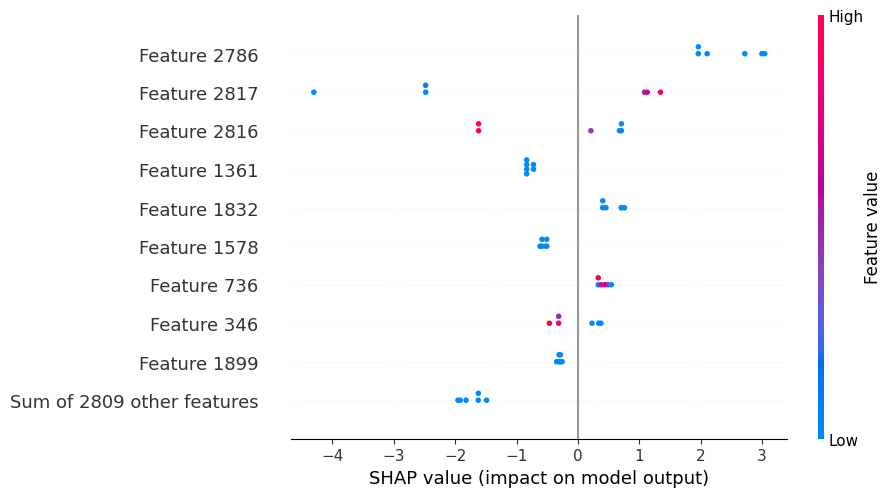

In [70]:
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test[:50])
shap.plots.beeswarm(shap_values)


In [52]:
# Make sure to use the same scaler you used during training
follow_features_test = test_df[['followersCount', 'followsCount']].fillna(0)
follow_features_test_scaled = scaler.transform(follow_features_test)


In [53]:
# ✅ Cell 5: Combine Only BERT features for prediction (since model expects 768 features)
X_test = text_features_test  # shape: (6, 768)


In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ✅ Combine text and numeric features — same as used in training
X_test = np.hstack([text_features_test, follow_features_test_scaled])

# 🔍 Predict without revealing ground truth
y_pred = model.predict(X_test)

# ✅ Evaluate against the hidden ground truth
print("✅ Accuracy:", accuracy_score(true_labels, y_pred))
print("\n📄 Classification Report:\n", classification_report(true_labels, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(true_labels, y_pred))

# ✅ Add predictions for manual inspection
test_df['actual_fake_account'] = true_labels
test_df['predicted_fake_account'] = y_pred

print("\n🔍 Prediction Results:")
print(test_df[['username', 'biography', 'actual_fake_account', 'predicted_fake_account']])


ValueError: Feature shape mismatch, expected: 768, got 770